# **NN Prediction Model**

---
## **1. Big Picture and Objectives**

### **Objective**
By June 2026 (end of the Premier League season), develop and evaluate a feedforward (Sequential) neural network that predicts Premier League match outcomes (home win, draw, away win) using historical FBref data scraped from FBref, achieving a **Macro F1-score of at least 0.70** on a held-out test season, while applying the concepts learned in the 'Neural Networks and Deep Learning' course by deeplearning.ai (forward/backward propagation, gradient descent, regularization, and hyperparameter tuning).

> **Why Macro F1 over Accuracy?** The dataset is imbalanced (Home Win ~45%, Away Win ~30%, Draw ~25%). A naive model predicting "Home Win" always achieves ~45% accuracy without learning anything. Macro F1 weights all three classes equally, ensuring the model genuinely learns to predict draws and away wins — not just the dominant class.

### **Similar Projects**
The next are good examples of similar projects that have applied neural networks and machine learning techniques to predict football match outcomes:



- **[lorenzopalaia/Football-Prediction](https://github.com/lorenzopalaia/Football-Prediction)** (Palaia, 2024): Keras NN on historical data; full notebooks for prep/training/eval.
- **[giovannicampa/football_match_results_prediction](https://github.com/giovannicampa/football_match_results_prediction)** (Campa, 2019): MLP/TensorFlow predict goals/outcomes; 55–59% accuracy.
- **[AndrewCarterUK/football-predictor](https://github.com/AndrewCarterUK/football-predictor)** (Carter, 2018): Deep NN for Premier League using team stats.
- **[yuliang419/football-predictor](https://github.com/yuliang419/football-predictor)** (Yuliang, 2022): Simple NN for EPL from recent performance.

### **Potential Pipeline**
Get data (FBref historical match data) → Preprocess (clean, feature engineering) → Train/Test split → Build NN model (Keras Sequential) → Train (forward/backward prop, gradient descent) → Evaluate (Macro F1-score on test set) → Hyperparameter tuning → Final evaluation.


---
## **2. Get the Data**

In [137]:
# read all csv files and add season from file names like fixtures_2015-2016.csv

import re
from pathlib import Path

import pandas as pd

cwd = Path.cwd()
path = cwd / "src" / "data"

if not path.exists():
    path = cwd.parent / "data"

if not path.exists():
    raise FileNotFoundError(f"Could not find data directory from {cwd}")

frames = []
for file in sorted(path.glob("*.csv")):
    season_match = re.search(r"fixtures_(\d{4}-\d{4})$", file.stem)
    season = season_match.group(1) if season_match else None

    temp_df = pd.read_csv(file)
    temp_df["season"] = season
    frames.append(temp_df)

df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

df

,week,day,date,time,home,score,away,attendance,venue,referee,match_report,season
0,1.0,Sat,2015-08-08,12:45(06:45),Manchester Utd,1–0,Tottenham Hotspur,75261.0,Old Trafford,Jonathan Moss,https://fbref.com/en/matches/86cdfeba/Manchest...,2015-2016
1,1.0,Sat,2015-08-08,15:00(09:00),Leicester City,4–2,Sunderland,32242.0,King Power Stadium,Lee Mason,https://fbref.com/en/matches/a6cda14d/Leiceste...,2015-2016
2,1.0,Sat,2015-08-08,15:00(09:00),Bournemouth,0–1,Aston Villa,11155.0,Vitality Stadium,Mark Clattenburg,https://fbref.com/en/matches/df747efb/Bournemo...,2015-2016
3,1.0,Sat,2015-08-08,15:00(09:00),Everton,2–2,Watford,39063.0,Goodison Park,Mike Jones,https://fbref.com/en/matches/ac0bb534/Everton-...,2015-2016
4,1.0,Sat,2015-08-08,15:00(09:00),Norwich City,1–3,Crystal Palace,27036.0,Carrow Road,Simon Hooper,https://fbref.com/en/matches/47257ad7/Norwich-...,2015-2016
...,...,...,...,...,...,...,...,...,...,...,...,...
4691,38.0,Sun,2026-05-24,16:00(10:00),Liverpool,NaN,Brentford,NaN,Anfield,NaN,https://fbref.com/en/stathead/matchup/teams/cd...,2025-2026
4692,38.0,Sun,2026-05-24,16:00(10:00),Burnley,NaN,Wolves,NaN,Turf Moor,NaN,https://fbref.com/en/stathead/matchup/teams/94...,2025-2026
4693,38.0,Sun,2026-05-24,16:00(10:00),West Ham United,NaN,Leeds United,NaN,London Stadium,NaN,https://fbref.com/en/stathead/matchup/teams/7c...,2025-2026
4694,38.0,Sun,2026-05-24,16:00(10:00),Manchester City,NaN,Aston Villa,NaN,Etihad Stadium,NaN,https://fbref.com/en/stathead/matchup/teams/b8...,2025-2026


---
## **3. Exploratory Analysis and Insights**

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4696 entries, 0 to 4695
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   week          4180 non-null   float64
 1   day           4180 non-null   str    
 2   date          4180 non-null   str    
 3   time          4180 non-null   str    
 4   home          4180 non-null   str    
 5   score         4101 non-null   str    
 6   away          4180 non-null   str    
 7   attendance    3660 non-null   float64
 8   venue         4180 non-null   str    
 9   referee       4101 non-null   str    
 10  match_report  4179 non-null   str    
 11  season        4696 non-null   str    
dtypes: float64(2), str(10)
memory usage: 440.4 KB


In [139]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
week,4180.0,19.500000,10.967168,1.0,10.00,19.5,29.00,38.0
attendance,3660.0,38483.679508,16802.489603,2000.0,25532.75,32233.5,52986.75,83222.0


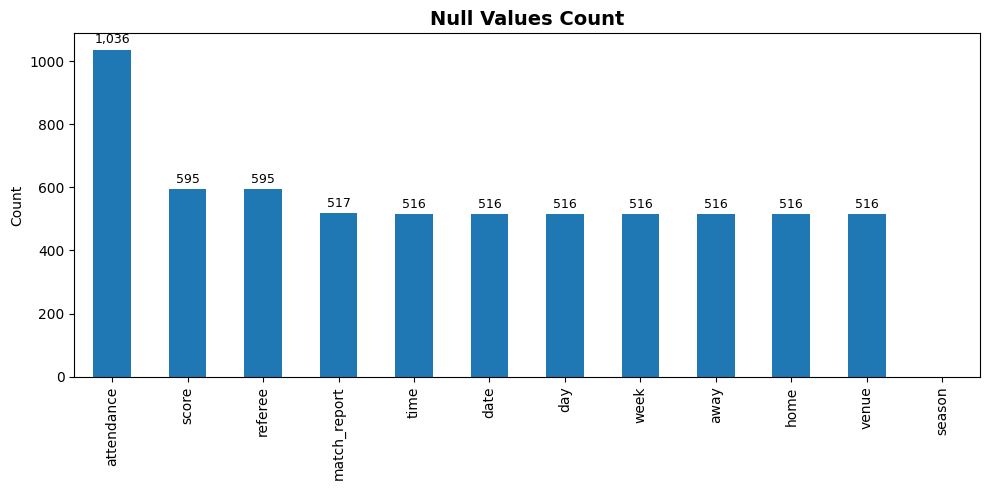

In [140]:
import matplotlib.pyplot as plt

# Null values count
null_counts = df.isnull().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = null_counts.plot(kind="bar", ax=ax)
ax.set_title("Null Values Count", fontsize=14, fontweight="bold")

for bar in ax.patches:
    value = int(bar.get_height())
    if value > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(null_counts) * 0.01,
            f"{value:,}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [141]:
# Count of rows with all null values
int(df.isnull().all(axis=1).sum())

0

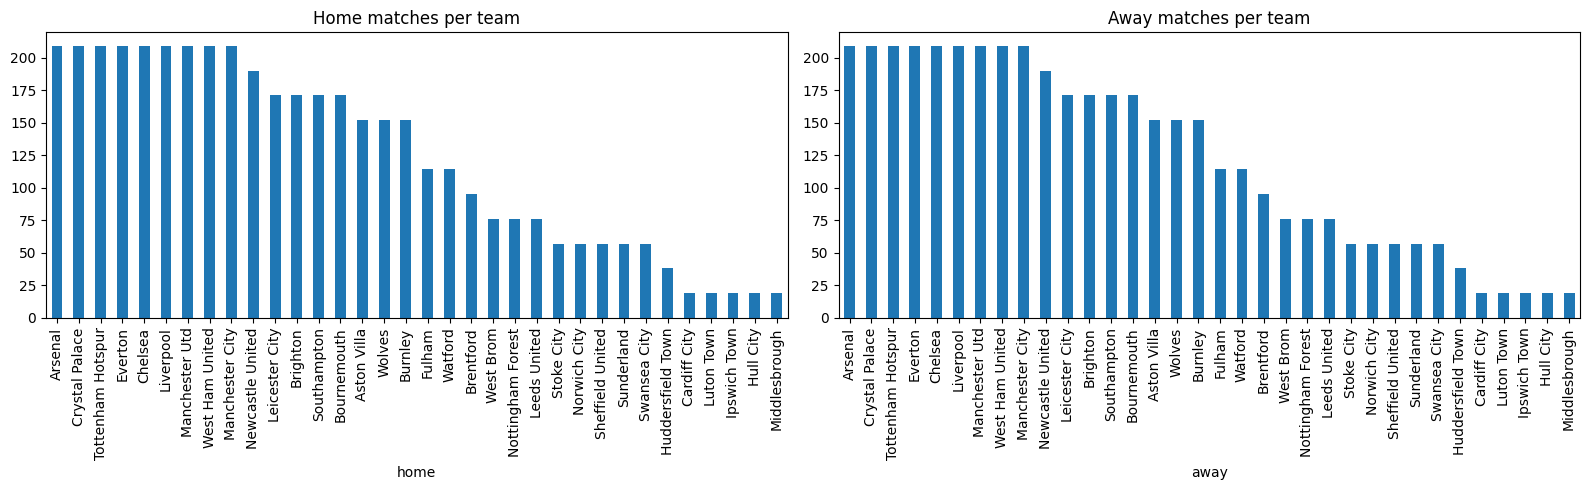

In [142]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

df["home"].groupby(
    df["home"]
).count(
).sort_values(
    ascending=False
).plot(
    kind="bar", ax=ax1
)
ax1.set_title("Home matches per team")

df["away"].groupby(
    df["away"]
).count(
).sort_values(
    ascending=False
).plot(
    kind="bar", ax=ax2
)
ax2.set_title("Away matches per team")

plt.tight_layout()
plt.show()


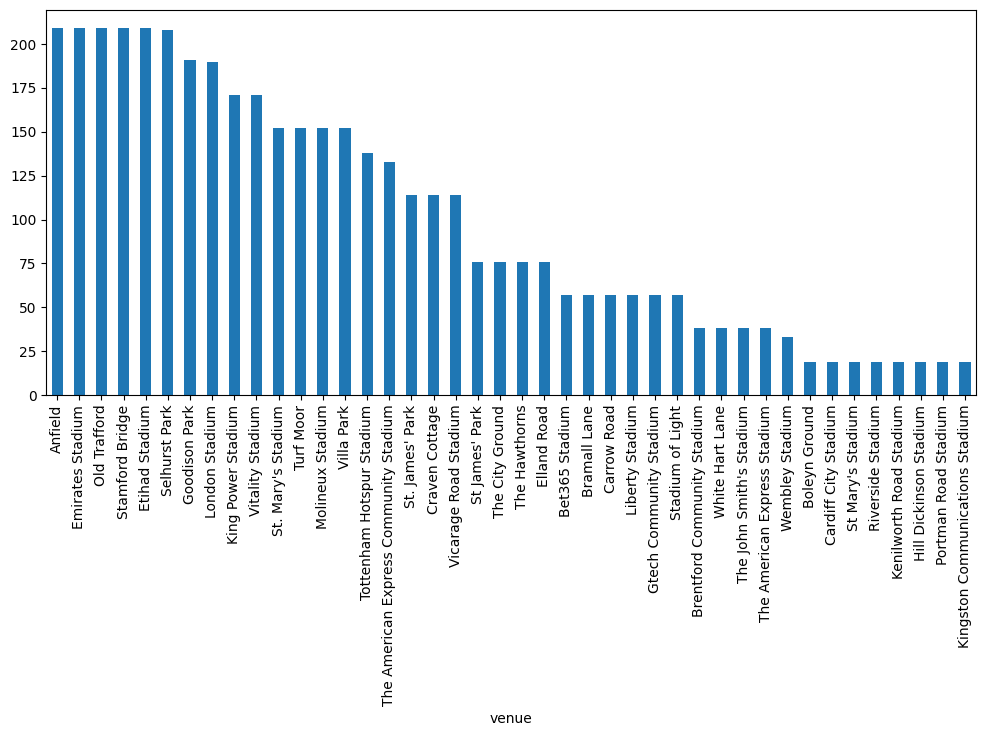

In [143]:
df["venue"].groupby(
    df["venue"]).count().sort_values(
    ascending=False
).plot(
    kind="bar", figsize=(12, 5)
);

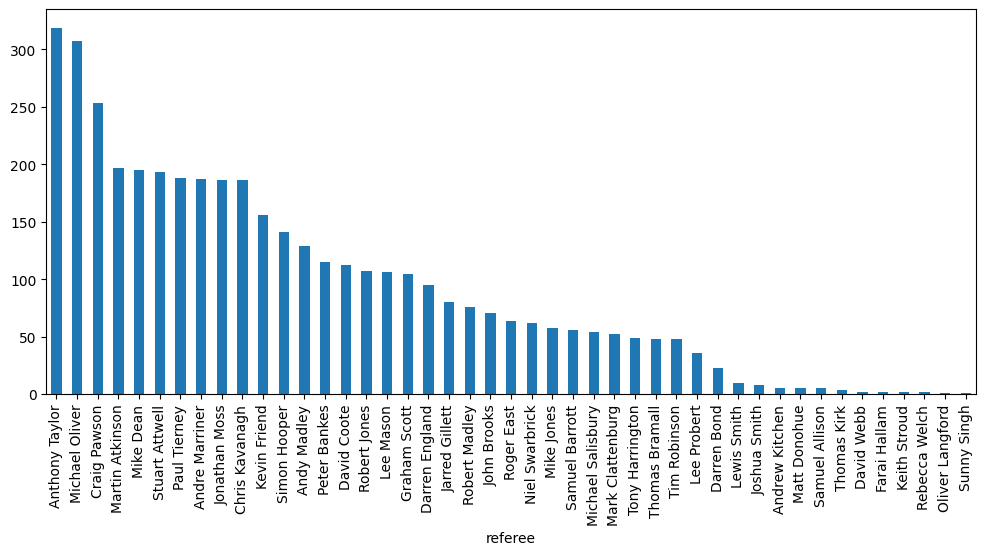

In [144]:
df["referee"].groupby(
    df["referee"]).count().sort_values(
    ascending=False
).plot(
    kind="bar", figsize=(12, 5)
);

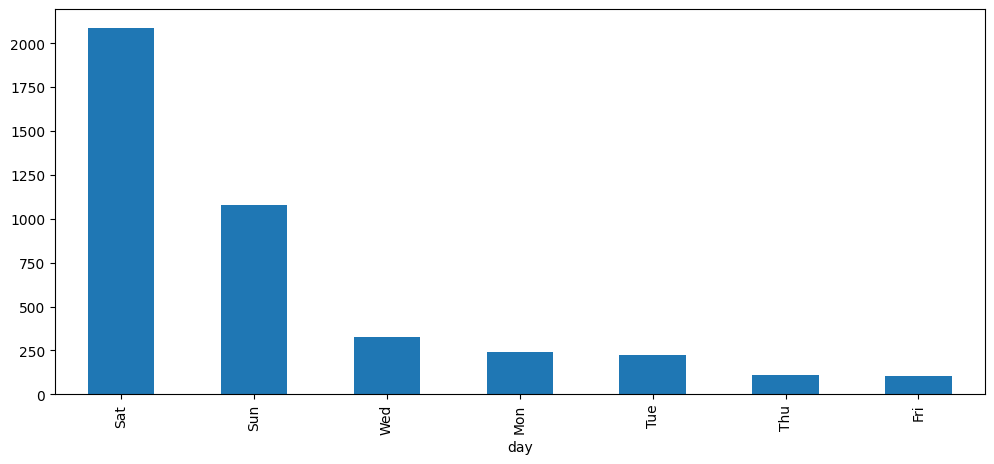

In [145]:
df["day"].groupby(
    df["day"]).count().sort_values(
    ascending=False
).plot(
    kind="bar", figsize=(12, 5)
);

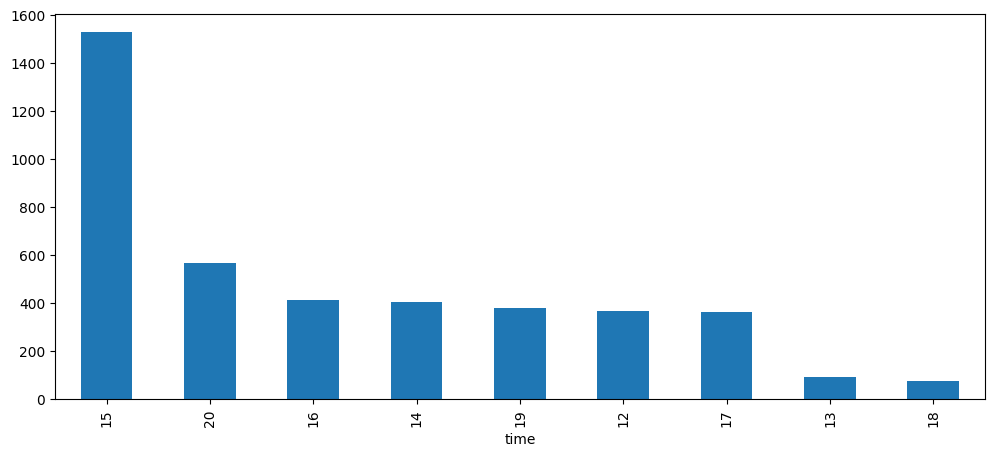

In [146]:
local_hour = pd.to_numeric(df["time"].str[:2], errors="coerce").dropna().astype(int)

local_hour.groupby(local_hour).count().sort_values(
    ascending=False
).plot(
    kind="bar", figsize=(12, 5)
);


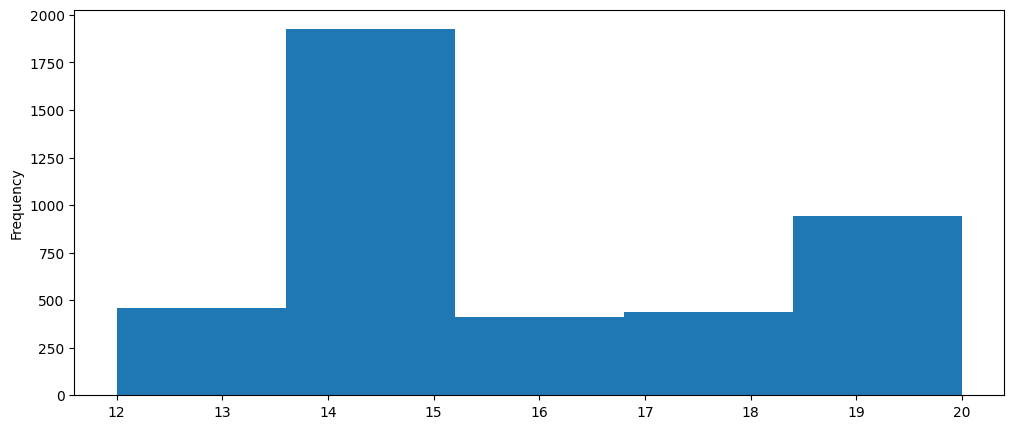

In [147]:
local_hour.plot(kind="hist", bins=5, figsize=(12, 5));

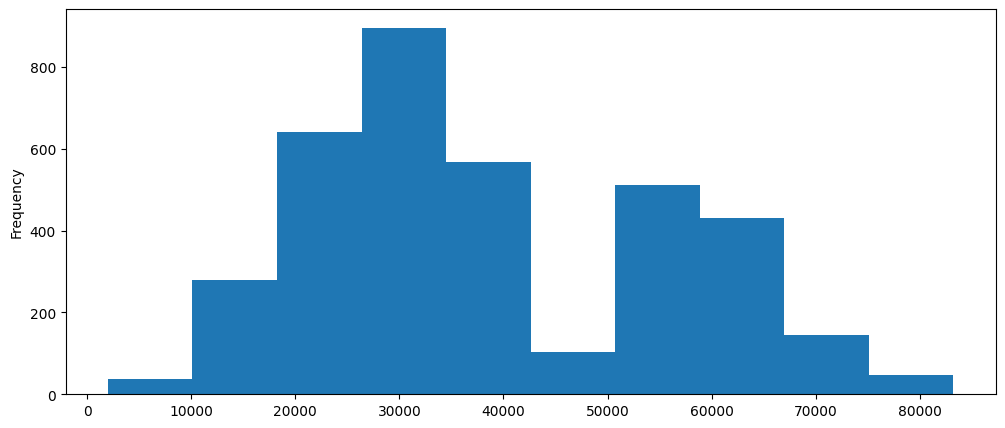

In [148]:
df["attendance"].plot(kind="hist", bins=10, figsize=(12, 5));

In [149]:
df_eda = df.copy()

In [150]:
df_eda

,week,day,date,time,home,score,away,attendance,venue,referee,match_report,season
0,1.0,Sat,2015-08-08,12:45(06:45),Manchester Utd,1–0,Tottenham Hotspur,75261.0,Old Trafford,Jonathan Moss,https://fbref.com/en/matches/86cdfeba/Manchest...,2015-2016
1,1.0,Sat,2015-08-08,15:00(09:00),Leicester City,4–2,Sunderland,32242.0,King Power Stadium,Lee Mason,https://fbref.com/en/matches/a6cda14d/Leiceste...,2015-2016
2,1.0,Sat,2015-08-08,15:00(09:00),Bournemouth,0–1,Aston Villa,11155.0,Vitality Stadium,Mark Clattenburg,https://fbref.com/en/matches/df747efb/Bournemo...,2015-2016
3,1.0,Sat,2015-08-08,15:00(09:00),Everton,2–2,Watford,39063.0,Goodison Park,Mike Jones,https://fbref.com/en/matches/ac0bb534/Everton-...,2015-2016
4,1.0,Sat,2015-08-08,15:00(09:00),Norwich City,1–3,Crystal Palace,27036.0,Carrow Road,Simon Hooper,https://fbref.com/en/matches/47257ad7/Norwich-...,2015-2016
...,...,...,...,...,...,...,...,...,...,...,...,...
4691,38.0,Sun,2026-05-24,16:00(10:00),Liverpool,NaN,Brentford,NaN,Anfield,NaN,https://fbref.com/en/stathead/matchup/teams/cd...,2025-2026
4692,38.0,Sun,2026-05-24,16:00(10:00),Burnley,NaN,Wolves,NaN,Turf Moor,NaN,https://fbref.com/en/stathead/matchup/teams/94...,2025-2026
4693,38.0,Sun,2026-05-24,16:00(10:00),West Ham United,NaN,Leeds United,NaN,London Stadium,NaN,https://fbref.com/en/stathead/matchup/teams/7c...,2025-2026
4694,38.0,Sun,2026-05-24,16:00(10:00),Manchester City,NaN,Aston Villa,NaN,Etihad Stadium,NaN,https://fbref.com/en/stathead/matchup/teams/b8...,2025-2026


In [151]:
df_eda["weekday"] = pd.to_datetime(df_eda["date"], errors="coerce").dt.weekday + 1
df_eda["month"] = pd.to_datetime(df_eda["date"], errors="coerce").dt.month
df_eda["hour"] = pd.to_numeric(df_eda["time"].str[:2], errors="coerce").dropna().astype(int)

In [152]:
def label_home_outcome(score):
    if pd.isna(score):
        return None
    try:
        home_score, away_score = map(int, score.split("–"))
        if home_score > away_score:
            return 1
        elif home_score < away_score:
            return -1
        else:
            return 0
    except Exception as e:
        print(f"Error encoding score '{score}': {e}")
        return None
    
df_eda["home_outcome"] = df_eda["score"].apply(label_home_outcome)

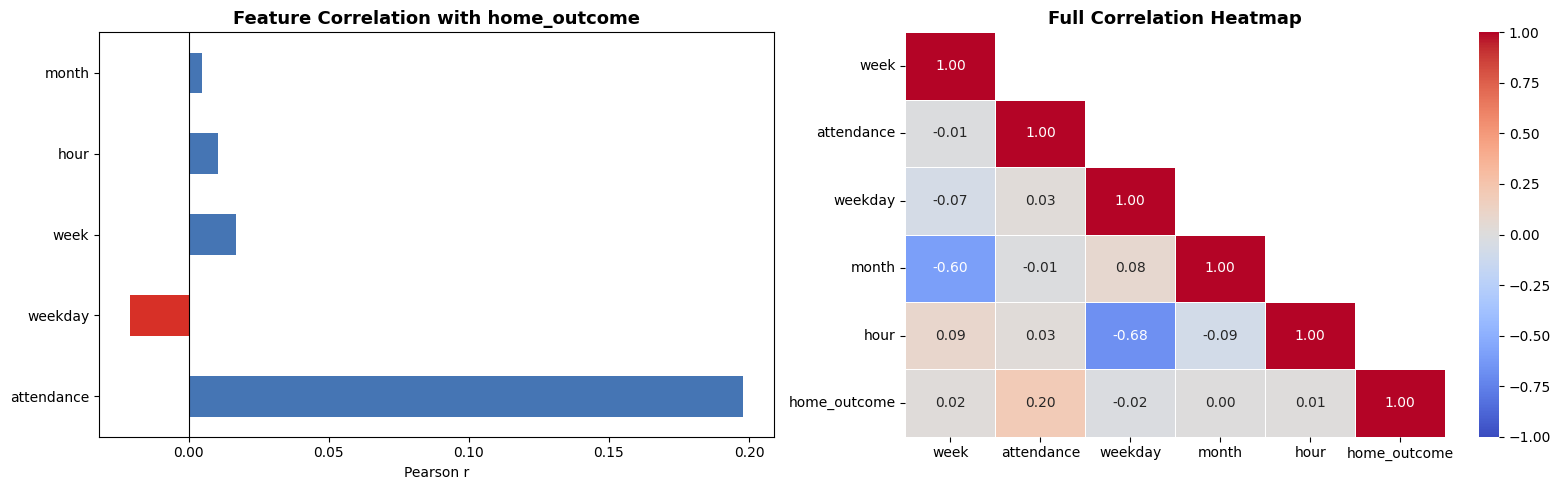

In [153]:
import numpy as np
import seaborn as sns

corr_matrix = df_eda.corr(numeric_only=True)

# Sort by absolute correlation with home_outcome
target = "home_outcome"
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: correlation of each feature with home_outcome
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_with_target]
corr_with_target.plot(kind="barh", ax=axes[0], color=colors)
axes[0].set_title(f"Feature Correlation with {target}", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Pearson r")
axes[0].axvline(0, color="black", linewidth=0.8)

# Heatmap: lower triangle only (includes diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1, mask=mask)
axes[1].set_title("Full Correlation Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [154]:
df_eda.head(10)

,week,day,date,time,home,score,away,attendance,venue,referee,match_report,season,weekday,month,hour,home_outcome
0,1.0,Sat,2015-08-08,12:45(06:45),Manchester Utd,1–0,Tottenham Hotspur,75261.0,Old Trafford,Jonathan Moss,https://fbref.com/en/matches/86cdfeba/Manchest...,2015-2016,6.0,8.0,12.0,1.0
1,1.0,Sat,2015-08-08,15:00(09:00),Leicester City,4–2,Sunderland,32242.0,King Power Stadium,Lee Mason,https://fbref.com/en/matches/a6cda14d/Leiceste...,2015-2016,6.0,8.0,15.0,1.0
2,1.0,Sat,2015-08-08,15:00(09:00),Bournemouth,0–1,Aston Villa,11155.0,Vitality Stadium,Mark Clattenburg,https://fbref.com/en/matches/df747efb/Bournemo...,2015-2016,6.0,8.0,15.0,-1.0
3,1.0,Sat,2015-08-08,15:00(09:00),Everton,2–2,Watford,39063.0,Goodison Park,Mike Jones,https://fbref.com/en/matches/ac0bb534/Everton-...,2015-2016,6.0,8.0,15.0,0.0
4,1.0,Sat,2015-08-08,15:00(09:00),Norwich City,1–3,Crystal Palace,27036.0,Carrow Road,Simon Hooper,https://fbref.com/en/matches/47257ad7/Norwich-...,2015-2016,6.0,8.0,15.0,-1.0
5,1.0,Sat,2015-08-08,17:30(11:30),Chelsea,2–2,Swansea City,41232.0,Stamford Bridge,Michael Oliver,https://fbref.com/en/matches/f3ff91b0/Chelsea-...,2015-2016,6.0,8.0,17.0,0.0
6,1.0,Sun,2015-08-09,13:30(07:30),Arsenal,0–2,West Ham United,59996.0,Emirates Stadium,Martin Atkinson,https://fbref.com/en/matches/71fb3701/Arsenal-...,2015-2016,7.0,8.0,13.0,-1.0
7,1.0,Sun,2015-08-09,13:30(07:30),Newcastle United,2–2,Southampton,49019.0,St. James' Park,Craig Pawson,https://fbref.com/en/matches/46264921/Newcastl...,2015-2016,7.0,8.0,13.0,0.0
8,1.0,Sun,2015-08-09,16:00(10:00),Stoke City,0–1,Liverpool,27654.0,Bet365 Stadium,Anthony Taylor,https://fbref.com/en/matches/2f5966ce/Stoke-Ci...,2015-2016,7.0,8.0,16.0,-1.0
9,1.0,Mon,2015-08-10,20:00(14:00),West Brom,0–3,Manchester City,24564.0,The Hawthorns,Mike Dean,https://fbref.com/en/matches/ea283763/West-Bro...,2015-2016,1.0,8.0,20.0,-1.0


In [155]:
df_eda.sort_values("date", inplace=True)

In [156]:
def add_venue_form_last_n(
    df: pd.DataFrame,
    n: int = 5,
    outcome_col: str = "home_outcome",
    season_col: str = "season",
    home_col: str = "home",
    away_col: str = "away",
) -> pd.DataFrame:
    """Add venue-specific rolling form columns to *df* and return it.

    Columns added:
      - home_team_home_matches_form_balance_last_n
      - away_team_away_matches_form_balance_last_n
    """
    out = df.copy()
    out[f"home_team_home_matches_form_balance_last_{n}"] = (
        out.groupby([season_col, home_col])[outcome_col]
        .transform(lambda s: s.shift(1).rolling(n, min_periods=1).sum())
        .fillna(0)
    )
    out[f"away_team_away_matches_form_balance_last_{n}"] = (
        out.groupby([season_col, away_col])[outcome_col]
        .transform(lambda s: s.shift(1).rolling(n, min_periods=1).sum())
        .fillna(0)
        .mul(-1)
    )
    return out

df_eda = add_venue_form_last_n(df_eda, n=1)
df_eda = add_venue_form_last_n(df_eda, n=3)
df_eda = add_venue_form_last_n(df_eda, n=5)
df_eda = add_venue_form_last_n(df_eda, n=10)

In [157]:
df_eda[df_eda["away"] == "Manchester Utd"].head(10)

,week,day,date,time,home,score,away,attendance,venue,referee,...,hour,home_outcome,home_team_home_matches_form_balance_last_1,away_team_away_matches_form_balance_last_1,home_team_home_matches_form_balance_last_3,away_team_away_matches_form_balance_last_3,home_team_home_matches_form_balance_last_5,away_team_away_matches_form_balance_last_5,home_team_home_matches_form_balance_last_10,away_team_away_matches_form_balance_last_10
11,2.0,Fri,2015-08-14,19:45(13:45),Aston Villa,0–1,Manchester Utd,42200.0,Villa Park,Mike Dean,...,19.0,-1.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
42,4.0,Sun,2015-08-30,16:00(10:00),Swansea City,2–1,Manchester Utd,20828.0,Liberty Stadium,Martin Atkinson,...,16.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
63,6.0,Sun,2015-09-20,16:00(10:00),Southampton,2–3,Manchester Utd,31588.0,St. Mary's Stadium,Mark Clattenburg,...,16.0,-1.0,1.0,-1.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
85,8.0,Sun,2015-10-04,16:00(10:00),Arsenal,3–0,Manchester Utd,60084.0,Emirates Stadium,Anthony Taylor,...,16.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
89,9.0,Sat,2015-10-17,15:00(09:00),Everton,0–3,Manchester Utd,39553.0,Goodison Park,Jonathan Moss,...,15.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-0.0,0.0,-0.0
111,11.0,Sat,2015-10-31,15:00(10:00),Crystal Palace,0–0,Manchester Utd,24854.0,Selhurst Park,Mike Jones,...,15.0,0.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,1.0
132,13.0,Sat,2015-11-21,12:45(07:45),Watford,1–2,Manchester Utd,20702.0,Vicarage Road Stadium,Robert Madley,...,12.0,-1.0,1.0,-0.0,-1.0,-0.0,0.0,-0.0,0.0,1.0
148,14.0,Sat,2015-11-28,17:30(12:30),Leicester City,1–1,Manchester Utd,32115.0,King Power Stadium,Craig Pawson,...,17.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,3.0,2.0
170,16.0,Sat,2015-12-12,17:30(12:30),Bournemouth,2–1,Manchester Utd,11334.0,Vitality Stadium,Anthony Taylor,...,17.0,1.0,0.0,-0.0,-2.0,1.0,-1.0,1.0,-2.0,2.0
187,18.0,Sat,2015-12-26,12:45(07:45),Stoke City,2–0,Manchester Utd,27426.0,Bet365 Stadium,Kevin Friend,...,12.0,1.0,-1.0,-1.0,1.0,-0.0,1.0,1.0,-1.0,1.0


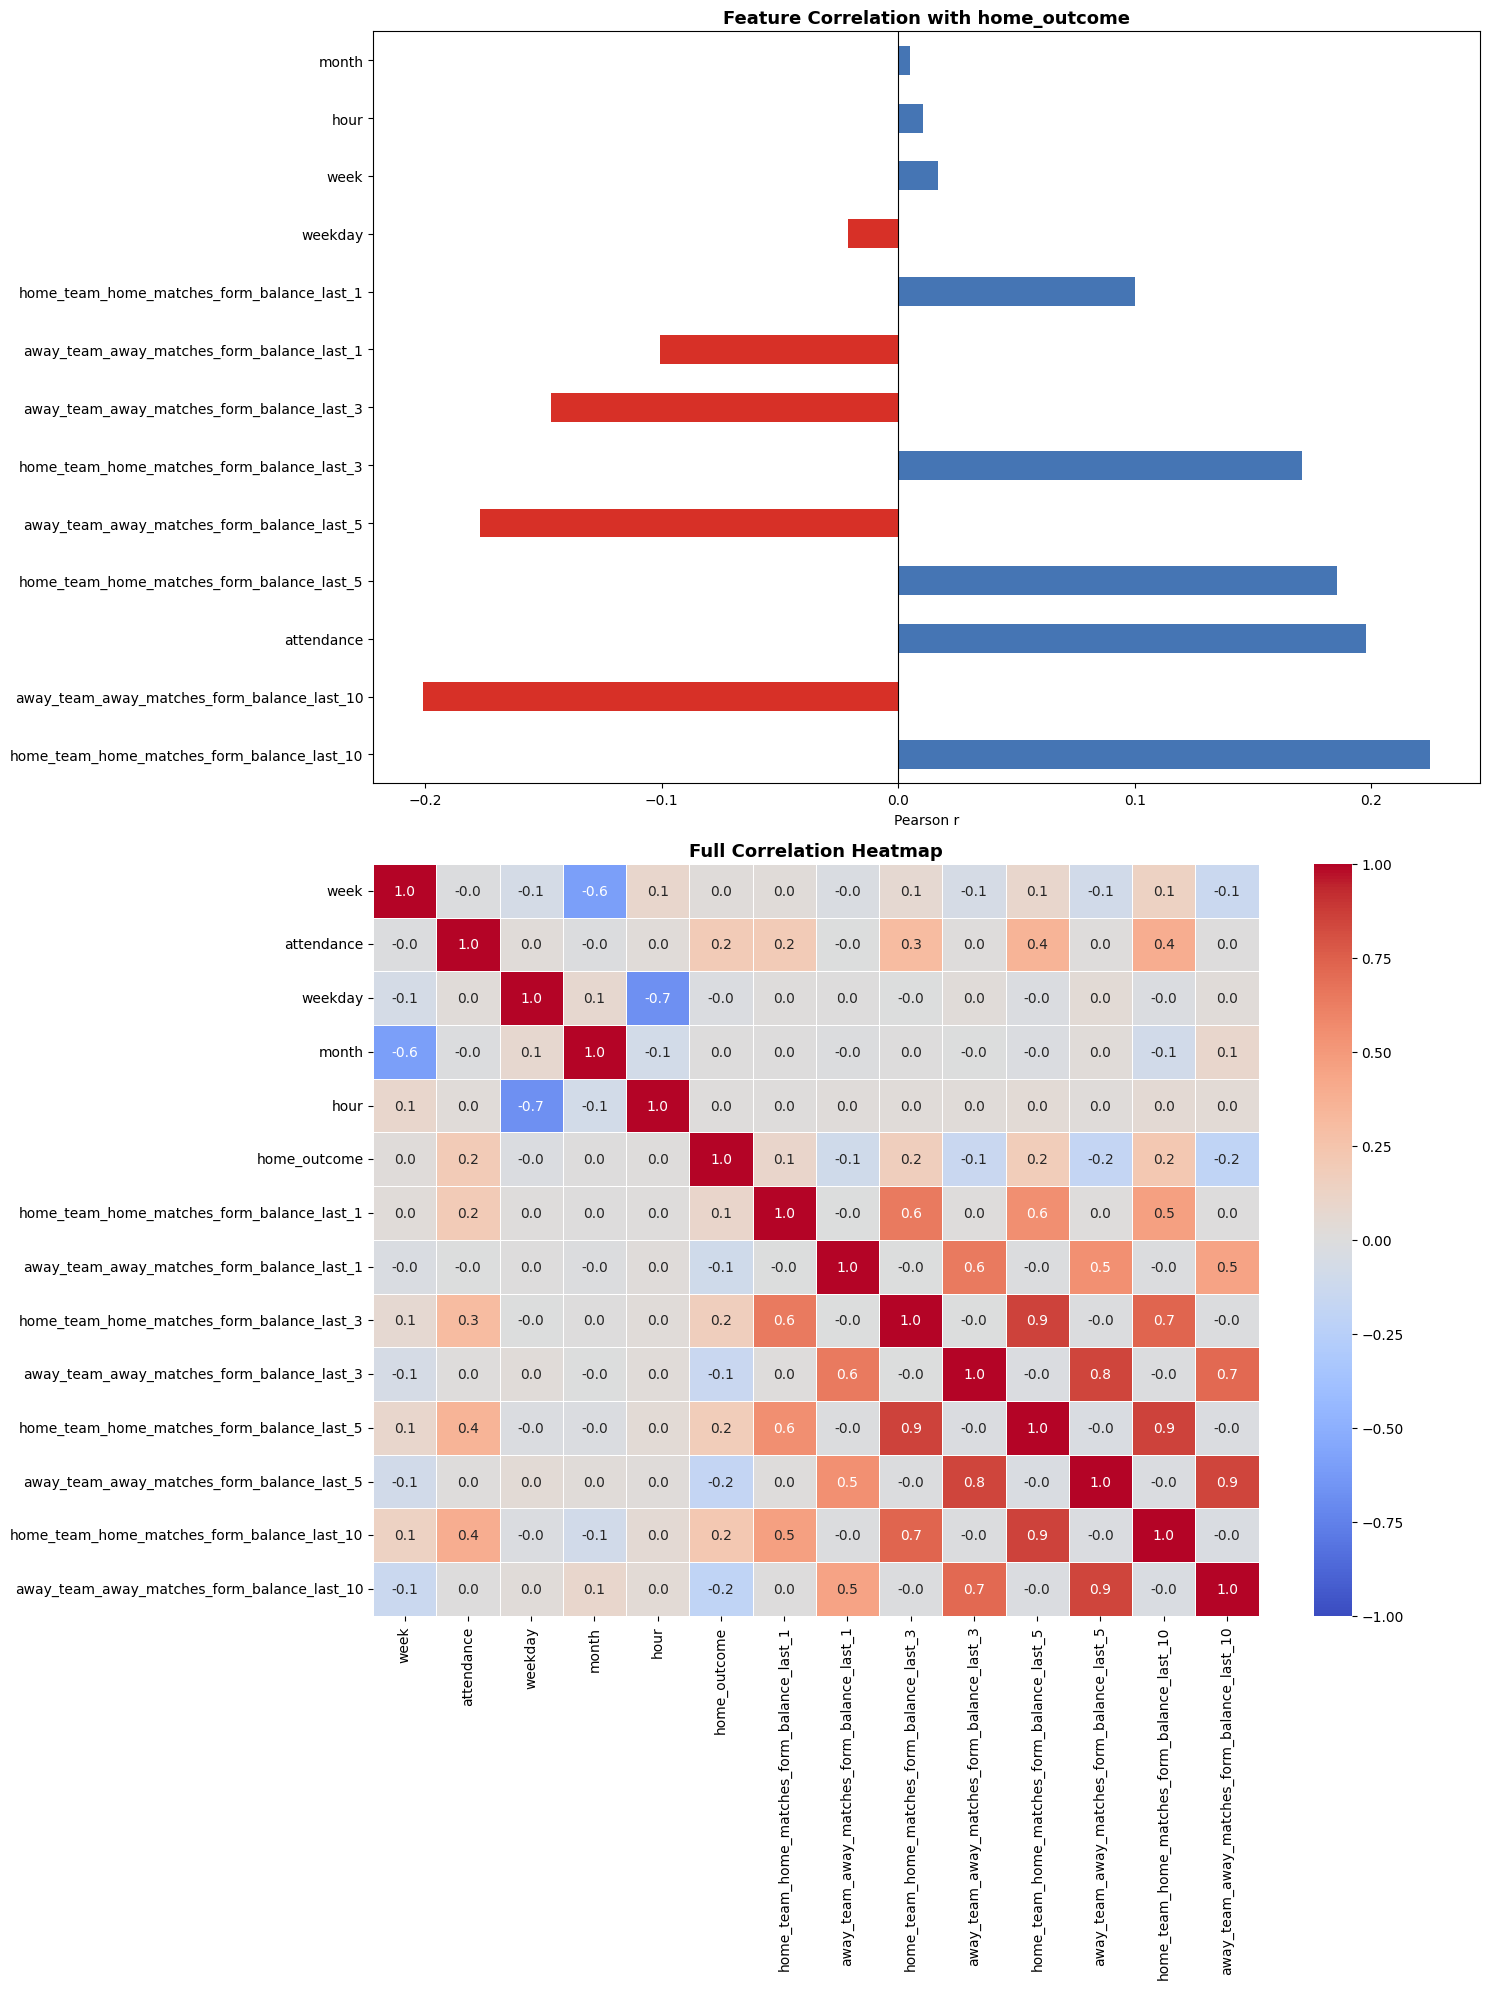

In [158]:
import seaborn as sns

corr_matrix = df_eda.corr(numeric_only=True)

# Sort by absolute correlation with home_outcome
target = "home_outcome"
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(15, 20))

# Bar chart: correlation of each feature with home_outcome
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_with_target]
corr_with_target.plot(kind="barh", ax=axes[0], color=colors)
axes[0].set_title(f"Feature Correlation with {target}", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Pearson r")
axes[0].axvline(0, color="black", linewidth=0.8)

# Heatmap: lower triangle only (includes diagonal)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Full Correlation Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [159]:
# TODO
# Add up the home team's results from the last 5 games, including both home and away matches.
# Add up the away team's results from the last 5 games, including both home and away matches.



In [160]:
import pandas as pd


def add_team_form_last_n(
    df: pd.DataFrame,
    n: int = 5,
    outcome_col: str = "home_outcome",
    season_col: str = "season",
    date_col: str = "date",
    time_col: str = "time",
    home_col: str = "home",
    away_col: str = "away",
) -> pd.DataFrame:
    out = df.copy()

    # Stable match id for merging features back
    out["_match_id"] = out.index

    # Build sortable kickoff datetime (date + time)
    date_part = pd.to_datetime(out[date_col], errors="coerce")
    time_part = pd.to_timedelta(out[time_col].fillna("00:00") + ":00", errors="coerce")
    out["_kickoff_dt"] = date_part + time_part.fillna(pd.Timedelta(0))

    # Team-centric history table:
    # - home team keeps home_outcome
    # - away team gets inverse outcome
    home_hist = out[["_match_id", season_col, "_kickoff_dt", home_col, outcome_col]].rename(
        columns={home_col: "team", outcome_col: "team_result"}
    )
    away_hist = out[["_match_id", season_col, "_kickoff_dt", away_col, outcome_col]].rename(
        columns={away_col: "team", outcome_col: "team_result"}
    )
    away_hist["team_result"] = -away_hist["team_result"]

    team_hist = pd.concat([home_hist, away_hist], ignore_index=True)
    team_hist = team_hist.sort_values([season_col, "team", "_kickoff_dt", "_match_id"])

    # Overall team form: all venues (home and away matches), excluding current match
    team_hist[f"overall_form_balance_last_{n}"] = (
        team_hist.groupby([season_col, "team"])["team_result"]
        .transform(lambda s: s.shift(1).rolling(n, min_periods=1).sum())
        .fillna(0)
    )

    # Merge back: one overall value for home team and one for away team
    home_form = team_hist[["_match_id", "team", f"overall_form_balance_last_{n}"]].rename(
        columns={"team": home_col, f"overall_form_balance_last_{n}": f"home_team_overall_form_balance_last_{n}"}
    )
    away_form = team_hist[["_match_id", "team", f"overall_form_balance_last_{n}"]].rename(
        columns={"team": away_col, f"overall_form_balance_last_{n}": f"away_team_overall_form_balance_last_{n}"}
    )

    out = out.merge(home_form, on=["_match_id", home_col], how="left")
    out = out.merge(away_form, on=["_match_id", away_col], how="left")

    return out.drop(columns=["_match_id", "_kickoff_dt"])


# Apply
df_eda = add_team_form_last_n(df_eda, n=1)
df_eda = add_team_form_last_n(df_eda, n=3)
df_eda = add_team_form_last_n(df_eda, n=5)
df_eda = add_team_form_last_n(df_eda, n=10)

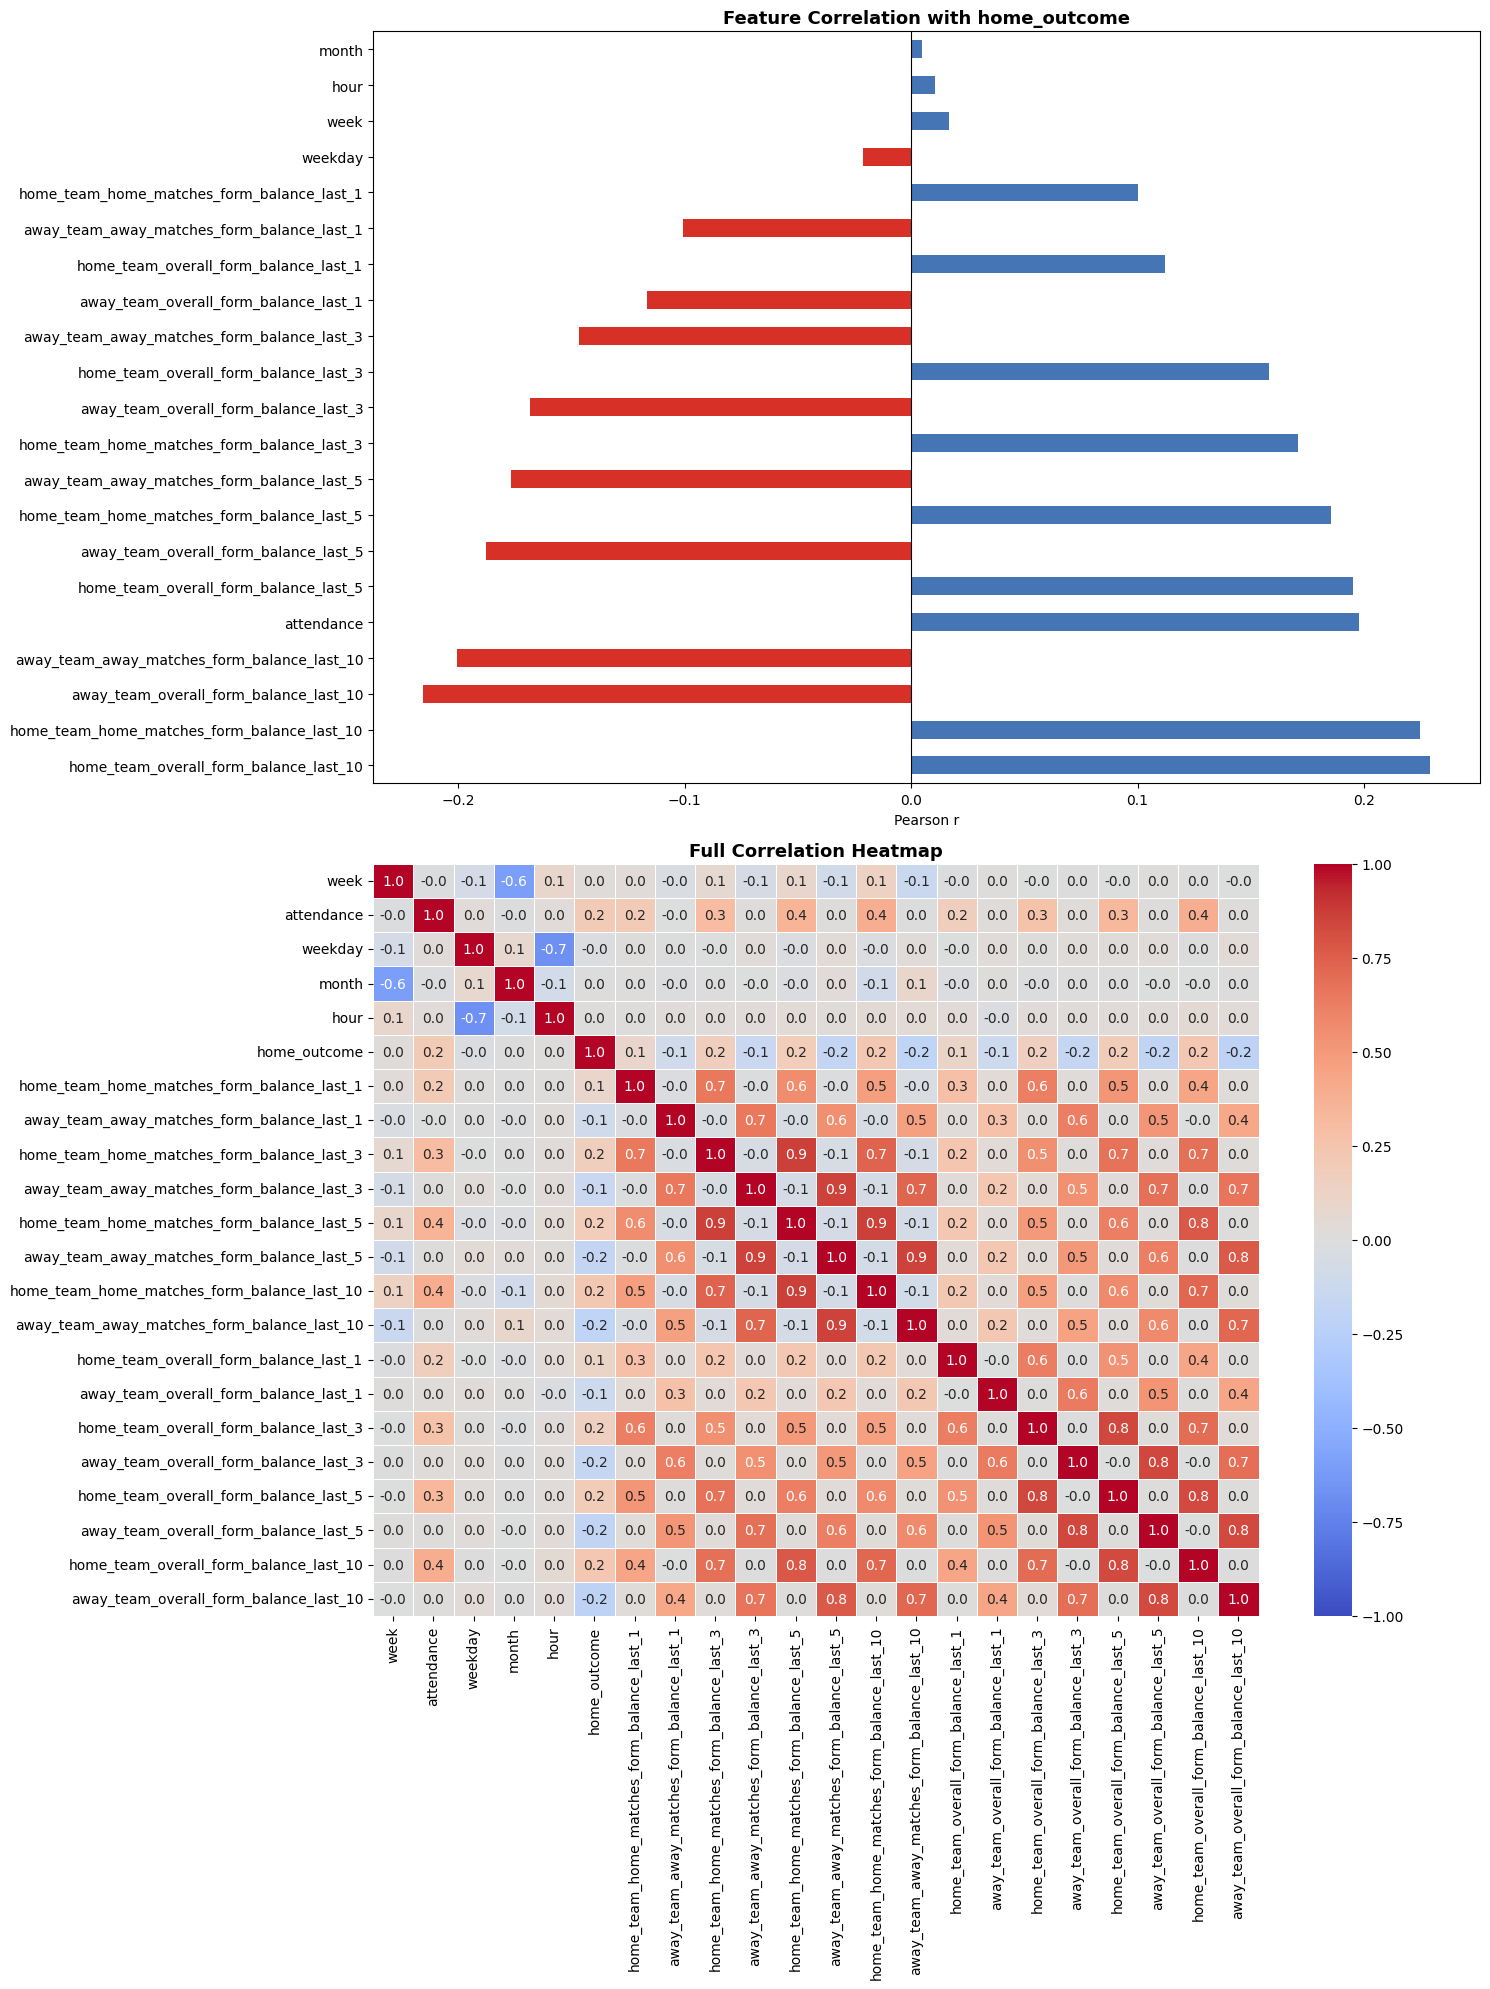

In [161]:
import numpy as np
import seaborn as sns

corr_matrix = df_eda.corr(numeric_only=True)

# Sort by absolute correlation with home_outcome
target = "home_outcome"
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(15, 20))

# Bar chart: correlation of each feature with home_outcome
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_with_target]
corr_with_target.plot(kind="barh", ax=axes[0], color=colors)
axes[0].set_title(f"Feature Correlation with {target}", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Pearson r")
axes[0].axvline(0, color="black", linewidth=0.8)

# Heatmap: lower triangle only (includes diagonal)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Full Correlation Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## **4. Data Preparation Pipeline**

In [162]:
def remove_x_with_all_nulls(X):
    return X.dropna(how="all", axis=0)